In [1]:
## import

import time
import torch
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import os
import cv2



## Training code for YOLO

In [2]:
import time
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

start_time = time.time()

model.train(
    data="pedestrian.yaml",
    epochs=50,
    imgsz=240,
    batch=16,
    device=0
)

yolo_train_time = time.time() - start_time

print("YOLO Training Time:", yolo_train_time)

New https://pypi.org/project/ultralytics/8.4.23 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.22  Python-3.13.5 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pedestrian.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=240, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=

## load yolo results 

In [3]:
import pandas as pd

results = pd.read_csv("C:/Users/Srinivas/Desktop/deep learning/runs/detect/train/results.csv")

yolo_precision = results["metrics/precision(B)"].iloc[-1]
yolo_recall = results["metrics/recall(B)"].iloc[-1]
yolo_map50 = results["metrics/mAP50(B)"].iloc[-1]
yolo_map5095 = results["metrics/mAP50-95(B)"].iloc[-1]

print("Precision:", yolo_precision)
print("Recall:", yolo_recall)
print("mAP50:", yolo_map50)
print("mAP50-95:", yolo_map5095)


Precision: 0.65005
Recall: 0.58151
mAP50: 0.61123
mAP50-95: 0.37131


Train R-CNN Model

In [7]:
import torch
import os
import cv2
import json
import time

from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor



# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# COLLATE FUNCTION
def collate_fn(batch):
    return tuple(zip(*batch))


# DATASET
class PedestrianDataset(Dataset):

    def __init__(self, img_dir, annotation_file):

        self.img_dir = img_dir

        with open(annotation_file) as f:
            data = json.load(f)

        self.images = data["images"]
        self.annotations = data["annotations"]

        self.targets = {}

        for ann in self.annotations:

            img_id = ann["image_id"]
            bbox = ann["bbox"]

            x1 = bbox[0]
            y1 = bbox[1]
            x2 = x1 + bbox[2]
            y2 = y1 + bbox[3]

            if img_id not in self.targets:
                self.targets[img_id] = []

            self.targets[img_id].append([x1, y1, x2, y2])


    def __len__(self):
        return len(self.images)


    def __getitem__(self, idx):

        img_info = self.images[idx]

        img_id = img_info["id"]
        img_name = img_info["file_name"]

        img_path = os.path.join(self.img_dir, img_name)

        img = cv2.imread(img_path)

        if img is None:
            raise ValueError("Image not found:", img_path)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = F.to_tensor(img)

        boxes = self.targets.get(img_id, [])
        boxes = torch.as_tensor(boxes, dtype=torch.float32)

        labels = torch.ones((boxes.shape[0],), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        return img, target


# DATASET
dataset = PedestrianDataset(
    "dataset/images/train",
    "dataset/rcnn_annotations/train.json"
)


# DATALOADER
loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

print("Dataset size:", len(dataset))


# MODEL
print("\nLoading Faster R-CNN model...")

weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model_rcnn = fasterrcnn_resnet50_fpn(weights=weights)

num_classes = 2

in_features = model_rcnn.roi_heads.box_predictor.cls_score.in_features
model_rcnn.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model_rcnn.to(device)
model_rcnn.train()

print("Model loaded successfully")


# OPTIMIZER
optimizer = torch.optim.Adam(model_rcnn.parameters(), lr=0.0001)


# TRAINING
start_time = time.time()

epochs = 3

print("\nStarting training...")

for epoch in range(epochs):

    epoch_loss = 0

    print(f"\nEpoch {epoch+1}/{epochs}")

    for batch_id, (images, targets) in enumerate(loader):

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model_rcnn(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

        if batch_id % 5 == 0:
            print("Batch:", batch_id, "Loss:", losses.item())

    print("Epoch Loss:", epoch_loss / len(loader))


training_time = time.time() - start_time

print("\nTraining finished")
print("Faster R-CNN Training Time:", training_time)



Using device: cuda
Dataset size: 160

Loading Faster R-CNN model...
Model loaded successfully

Starting training...

Epoch 1/3
Batch: 0 Loss: 0.8172577023506165
Batch: 5 Loss: 0.17335450649261475
Batch: 10 Loss: 0.23751190304756165
Batch: 15 Loss: 0.20057816803455353
Batch: 20 Loss: 0.31853288412094116
Batch: 25 Loss: 0.32907065749168396
Batch: 30 Loss: 0.3459927439689636
Batch: 35 Loss: 0.09610392898321152
Batch: 40 Loss: 0.12921534478664398
Batch: 45 Loss: 0.15565283596515656
Batch: 50 Loss: 0.38878554105758667
Batch: 55 Loss: 0.3857372999191284
Batch: 60 Loss: 0.1254301518201828
Batch: 65 Loss: 0.20012490451335907
Batch: 70 Loss: 0.14814868569374084
Batch: 75 Loss: 0.14916498959064484
Epoch Loss: 0.2681560946628451

Epoch 2/3
Batch: 0 Loss: 0.2876965403556824
Batch: 5 Loss: 0.23944798111915588
Batch: 10 Loss: 0.18914397060871124
Batch: 15 Loss: 0.1208900734782219
Batch: 20 Loss: 0.29946810007095337
Batch: 25 Loss: 0.0839896872639656
Batch: 30 Loss: 0.12462036311626434
Batch: 35 Loss

In [8]:
import torch
from torchvision.ops import box_iou

print("\nStarting evaluation...")

model_rcnn.eval()

total_tp = 0
total_fp = 0
total_fn = 0

iou_threshold = 0.5

with torch.no_grad():

    for images, targets in loader:

        images = [img.to(device) for img in images]
        outputs = model_rcnn(images)

        for output, target in zip(outputs, targets):

            pred_boxes = output["boxes"].cpu()
            pred_scores = output["scores"].cpu()

            gt_boxes = target["boxes"].cpu()

            if len(pred_boxes) == 0:
                total_fn += len(gt_boxes)
                continue

            ious = box_iou(pred_boxes, gt_boxes)

            matched_gt = set()

            for i in range(len(pred_boxes)):

                max_iou, gt_idx = torch.max(ious[i], dim=0)

                if max_iou >= iou_threshold and gt_idx.item() not in matched_gt:
                    total_tp += 1
                    matched_gt.add(gt_idx.item())
                else:
                    total_fp += 1

            total_fn += len(gt_boxes) - len(matched_gt)

# metrics
precision = total_tp / (total_tp + total_fp + 1e-6)
recall = total_tp / (total_tp + total_fn + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)

print("\nEvaluation Results")
print("----------------------")

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Starting evaluation...

Evaluation Results
----------------------
Precision: 0.21225071209953653
Recall: 0.9867549636200167
F1 Score: 0.3493549251014988


Inference Time Comparison

In [9]:
import numpy as np
import os
import cv2
import time
import torch
from torchvision.transforms import functional as F

test_images = os.listdir("dataset/images/test")[:50]

# YOLO inference time
yolo_model = YOLO("C:/Users/Srinivas/Desktop/deep learning/runs/detect/train/weights/best.pt")

start = time.time()

for img in test_images:
    yolo_model.predict(f"dataset/images/test/{img}", verbose=False)

yolo_inference = (time.time() - start) / len(test_images)


# RCNN inference
model_rcnn.eval()

start = time.time()

for img in test_images:

    image = cv2.imread(f"dataset/images/test/{img}")
    image = F.to_tensor(image).to(device)   # ✅ MOVE IMAGE TO GPU

    with torch.no_grad():
        model_rcnn([image])

rcnn_inference = (time.time() - start) / len(test_images)

print("YOLO inference time:", yolo_inference)
print("RCNN inference time:", rcnn_inference)

YOLO inference time: 0.03090908130009969
RCNN inference time: 0.15544595321019491


FPS calculation

In [10]:
yolo_fps = 1 / yolo_inference
rcnn_fps = 1 / rcnn_inference

print("YOLO FPS:", yolo_fps)
print("RCNN FPS:", rcnn_fps)


YOLO FPS: 32.35295123432785
RCNN FPS: 6.433104106916146


In [11]:
import os

yolo_size = os.path.getsize("C:/Users/Srinivas/Desktop/deep learning/runs/detect/train/weights/best.pt") / 1e6

torch.save(model_rcnn.state_dict(), "rcnn_model.pth")
rcnn_size = os.path.getsize("rcnn_model.pth") / 1e6

print("YOLO model size (MB):", yolo_size)
print("RCNN model size (MB):", rcnn_size)


YOLO model size (MB): 6.205098
RCNN model size (MB): 165.728568


Create comparision table 

In [12]:
metrics = model.val(data="pedestrian.yaml")

yolo_precision = metrics.box.p
yolo_recall = metrics.box.r
yolo_map = metrics.box.map50
yolo_map5095 = metrics.box.map

data = {

    "Metric":[
        "Precision",
        "Recall",
        "mAP",
        "Training Time",
        "Inference Time",
        "FPS",
        "Model Size"
    ],

    "YOLO":[
        yolo_precision,
        yolo_recall,
        yolo_map,
        yolo_train_time,
        yolo_inference,
        yolo_fps,
        yolo_size
    ],

    "RCNN":[
        precision,
        recall,
        None,
        training_time,
        rcnn_inference,
        rcnn_fps,
        rcnn_size
    ]
}

df = pd.DataFrame(data)
df


Ultralytics 8.4.22  Python-3.13.5 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 115.335.0 MB/s, size: 11.6 KB)
val: Scanning C:\Users\Srinivas\Desktop\deep learning\dataset\labels\val.cache... 47 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 47/47 7.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.7s/it 8.2s2.2s7s
                   all         47        115      0.706      0.626      0.637       0.38
Speed: 1.9ms preprocess, 22.5ms inference, 0.0ms loss, 5.0ms postprocess per image
Results saved to C:\Users\Srinivas\Desktop\deep learning\runs\detect\val


,Metric,YOLO,RCNN
0,Precision,[0.7061711144376818],0.212251
1,Recall,[0.6260869565217392],0.986755
2,mAP,0.636862,NaN
3,Training Time,489.39944,447.610170
4,Inference Time,0.030909,0.155446
5,FPS,32.352951,6.433104
6,Model Size,6.205098,165.728568


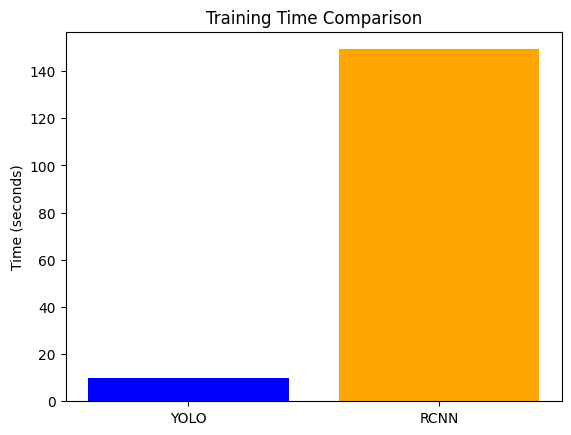

In [ ]:
#Comparison Graphs
%matplotlib inline

plt.bar(["YOLO","RCNN"], [yolo_train_time/50,training_time/3], color=["blue","orange"])
plt.title("Training Time Comparison")
plt.ylabel("Time (seconds)")
plt.show()

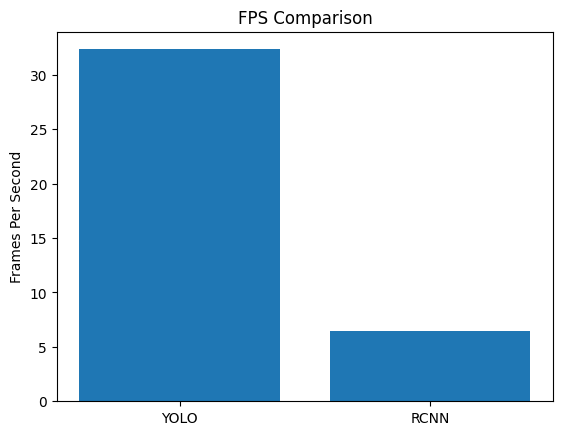

In [14]:
plt.bar(["YOLO","RCNN"], [yolo_fps, rcnn_fps])
plt.title("FPS Comparison")
plt.ylabel("Frames Per Second")
plt.show()


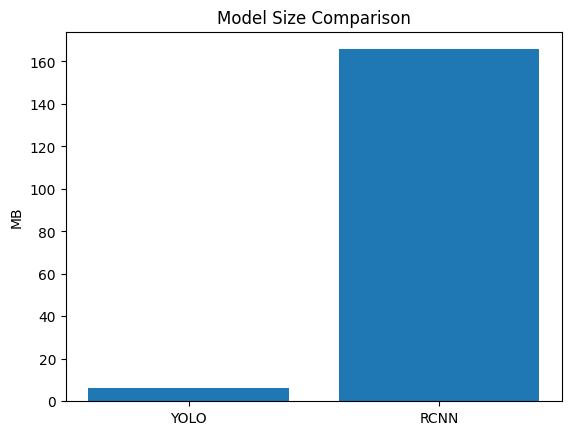

In [16]:
# Model Size
plt.bar(["YOLO","RCNN"], [yolo_size, rcnn_size])
plt.title("Model Size Comparison")
plt.ylabel("MB")
plt.show()
